In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("telecom_churn_data.csv")

In [3]:
df

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,...,0,1.0,1.0,1.0,NaN,968,30.40,0.00,101.20,3.58
1,7001865778,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,34.047,...,0,NaN,1.0,1.0,NaN,1006,0.00,0.00,0.00,0.00
2,7001625959,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,167.690,...,0,NaN,NaN,NaN,1.0,1103,0.00,0.00,4.17,0.00
3,7001204172,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,221.338,...,0,NaN,NaN,NaN,NaN,2491,0.00,0.00,0.00,0.00
4,7000142493,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,261.636,...,0,0.0,NaN,NaN,NaN,1526,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,7001548952,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,18.471,...,0,NaN,NaN,NaN,NaN,3199,0.00,0.00,0.00,0.00
99995,7000607688,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,112.201,...,0,NaN,NaN,NaN,NaN,2052,0.00,0.00,0.00,0.00
99996,7000087541,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,229.187,...,0,1.0,NaN,NaN,NaN,185,0.00,0.00,0.00,0.00
99997,7000498689,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,322.991,...,0,1.0,1.0,1.0,1.0,478,1445.74,1151.03,1173.18,0.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Columns: 226 entries, mobile_number to sep_vbc_3g
dtypes: float64(179), int64(35), object(12)
memory usage: 172.4+ MB


In [7]:
print(df.isnull().sum())

mobile_number        0
circle_id            0
loc_og_t2o_mou    1018
std_og_t2o_mou    1018
loc_ic_t2o_mou    1018
                  ... 
aon                  0
aug_vbc_3g           0
jul_vbc_3g           0
jun_vbc_3g           0
sep_vbc_3g           0
Length: 226, dtype: int64


In [8]:
date_cols = [col for col in df.columns if 'date' in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [9]:
df

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,197.385,...,0,1.0,1.0,1.0,NaN,968,30.40,0.00,101.20,3.58
1,7001865778,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,34.047,...,0,NaN,1.0,1.0,NaN,1006,0.00,0.00,0.00,0.00
2,7001625959,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,167.690,...,0,NaN,NaN,NaN,1.0,1103,0.00,0.00,4.17,0.00
3,7001204172,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,221.338,...,0,NaN,NaN,NaN,NaN,2491,0.00,0.00,0.00,0.00
4,7000142493,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,261.636,...,0,0.0,NaN,NaN,NaN,1526,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,7001548952,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,18.471,...,0,NaN,NaN,NaN,NaN,3199,0.00,0.00,0.00,0.00
99995,7000607688,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,112.201,...,0,NaN,NaN,NaN,NaN,2052,0.00,0.00,0.00,0.00
99996,7000087541,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,229.187,...,0,1.0,NaN,NaN,NaN,185,0.00,0.00,0.00,0.00
99997,7000498689,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,322.991,...,0,1.0,1.0,1.0,1.0,478,1445.74,1151.03,1173.18,0.00


In [10]:
# 1. Fill NaNs in recharge columns with 0
recharge_cols = ['total_rech_data_6', 'total_rech_data_7', 'av_rech_amt_data_6', 'av_rech_amt_data_7', 'total_rech_amt_6', 'total_rech_amt_7']
df[recharge_cols] = df[recharge_cols].fillna(0)

# 2. Calculate Total Recharge (Amount + Data Amount)
# Total Data Recharge = Number of data recharges * Average amount per data recharge
df['total_rech_6'] = df['total_rech_amt_6'] + (df['total_rech_data_6'] * df['av_rech_amt_data_6'])
df['total_rech_7'] = df['total_rech_amt_7'] + (df['total_rech_data_7'] * df['av_rech_amt_data_7'])

# Average of Month 6 and 7
df['avg_rech_6_7'] = (df['total_rech_6'] + df['total_rech_7']) / 2

# 3. Filter for High-Value Customers (>= 70th percentile)
threshold = df['avg_rech_6_7'].quantile(0.7)
df_high_value = df[df['avg_rech_6_7'] >= threshold].copy()

print(f"High-Value Threshold: {threshold}")
print(f"Remaining Rows: {df_high_value.shape[0]}")

High-Value Threshold: 478.0
Remaining Rows: 30001


In [13]:
# 4. Tag Churners (Target Variable)
# A customer churns if they have 0 voice AND 0 data usage in month 9
churn_indicators = ['total_ic_mou_9', 'total_og_mou_9', 'vol_2g_mb_9', 'vol_3g_mb_9']
df_high_value[churn_indicators] = df_high_value[churn_indicators].fillna(0)

# If sum of usage is 0, Churn = 1, else 0
df_high_value['churn'] = (df_high_value[churn_indicators].sum(axis=1) == 0).astype(int)



In [15]:
df_high_value

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g,total_rech_6,total_rech_7,avg_rech_6_7,churn
0,7000842753,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,197.385,...,NaN,968,30.40,0.00,101.20,3.58,614.0,504.0,559.0,1
7,7000701601,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,1069.180,...,NaN,802,57.74,19.38,18.74,0.00,1580.0,790.0,1185.0,1
8,7001524846,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,378.721,...,NaN,315,21.03,910.65,122.16,0.00,437.0,955.0,696.0,0
21,7002124215,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,514.453,...,NaN,720,0.00,0.00,0.00,0.00,600.0,680.0,640.0,0
23,7000887461,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,74.350,...,1.0,604,40.45,51.86,0.00,0.00,0.0,1166.0,583.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99981,7000630859,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,384.316,...,NaN,473,1100.43,619.59,668.05,0.33,504.0,624.0,564.0,0
99984,7000661676,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,328.594,...,1.0,820,0.00,0.00,0.00,0.00,514.0,723.0,618.5,0
99986,7001729035,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,644.973,...,1.0,2696,497.45,598.67,604.08,0.00,584.0,1144.0,864.0,0
99988,7002111859,109,0.0,0.0,0.0,2014-06-30,2014-07-31,2014-08-31,2014-09-30,312.558,...,1.0,328,104.73,0.00,0.00,0.00,380.0,708.0,544.0,0


In [16]:
# 5. Drop Month 9 columns (to avoid data leakage)
cols_9 = [col for col in df_high_value.columns if '_9' in col]
df_high_value.drop(columns=cols_9, inplace=True)

print(f"Churn Rate: {df_high_value['churn'].mean()*100:.2f}%")

Churn Rate: 8.14%


In [17]:
# Create a list of features to calculate the difference for
# We focus on Revenue (ARPU), Minutes of Use (MOU), and Recharge Amount
features_to_diff = ['arpu', 'total_og_mou', 'total_ic_mou', 'total_rech_amt', 'vol_2g_mb', 'vol_3g_mb']

for feat in features_to_diff:
    # Calculate the average of month 6 and 7 (Good Phase)
    avg_6_7 = (df_high_value[feat + '_6'] + df_high_value[feat + '_7']) / 2
    
    # Calculate the difference between month 8 and the Good Phase average
    # A negative value means usage dropped in month 8
    df_high_value[feat + '_diff'] = df_high_value[feat + '_8'] - avg_6_7

# Let's also create 'Age on Network' in years for better readability
df_high_value['aon_years'] = df_high_value['aon'] / 365

print("New Delta features created. Sample of 'arpu_diff':")
print(df_high_value[['arpu_6', 'arpu_7', 'arpu_8', 'arpu_diff']].head())

New Delta features created. Sample of 'arpu_diff':
      arpu_6    arpu_7    arpu_8  arpu_diff
0    197.385   214.816   213.803     7.7025
7   1069.180  1349.850  3171.480  1961.9650
8    378.721   492.223   137.362  -298.1100
21   514.453   597.753   637.760    81.6570
23    74.350   193.897   366.966   232.8425


In [18]:
import seaborn as sns

# Preprocessing and Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Settings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [19]:
# 1. Store the IDs separately before they are dropped from X
customer_ids = df_high_value['mobile_number']

# 2. Define X and y (dropping identifiers and target)
X = df_high_value.drop(['churn', 'mobile_number'], axis=1)
y = df_high_value['churn']

# 3. Split the data
# We include 'customer_ids' in the split so we know which ID belongs to which test row
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids, test_size=0.3, random_state=42, stratify=y
)

print(f"We have {len(id_test)} customer IDs ready for the outreach list later.")

We have 9001 customer IDs ready for the outreach list later.


In [25]:
# 1. Define your Features (X) and Target (y)
# We drop 'churn' (target) and 'mobile_number' (ID) from the training features
X_numeric = df_high_value.drop(['churn', 'mobile_number'], axis=1).select_dtypes(include=['number'])
y = df_high_value['churn']

# 2. Perform the split
# id_train and id_test will hold the mobile numbers
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, df_high_value['mobile_number'], 
    test_size=0.3, 
    random_state=42, 
    stratify=y # Keeps the 8.14% churn ratio consistent in both sets
)

print(f"Training rows: {len(X_train)} | Testing rows: {len(X_test)}")

Training rows: 21000 | Testing rows: 9001


In [28]:
# 1. Start fresh with the features
X = df_high_value.drop(['churn', 'mobile_number'], axis=1)

# 2. Force convert everything to numeric, turning 'objects' and 'dates' into NaN
# This is a 'brute force' way to ensure no Date objects are hiding in there
X_numeric = X.apply(pd.to_numeric, errors='coerce')

# 3. Drop columns that became entirely NaN (like the original Date columns)
X_numeric = X_numeric.dropna(axis=1, how='all')

# 4. Fill any remaining individual NaNs with 0
# (Sometimes a few rows have missing MOU values)
X_numeric = X_numeric.fillna(0)

# 5. Final check: verify there are ZERO non-numeric columns left
non_numeric_cols = X_numeric.select_dtypes(exclude=['number']).columns.tolist()
print(f"Non-numeric columns remaining: {non_numeric_cols}")

# 6. Re-split with the clean data
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X_numeric, y, df_high_value['mobile_number'], 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print("Data deep-cleaned. Ready for Scaler.")

Non-numeric columns remaining: []
Data deep-cleaned. Ready for Scaler.


In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaler success!")

Scaler success!


In [31]:
# Initialize and train the model
# max_iter is increased to ensure convergence on large datasets
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Get Predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_probs = lr_model.predict_proba(X_test_scaled)[:, 1] # Probability of churn

In [32]:
# Create the outreach dataframe
outreach_list = pd.DataFrame({
    'mobile_number': id_test,
    'churn_probability': y_pred_probs
})

# Sort by highest risk first and pick top 500 or 1000 for the marketing team
top_risk_customers = outreach_list.sort_values(by='churn_probability', ascending=False)

print("Sample Outreach List (Top 10 High-Risk Customers):")
print(top_risk_customers.head(10))

# To save this to a CSV for your team:
# top_risk_customers.to_csv('high_risk_outreach_list.csv', index=False)

Sample Outreach List (Top 10 High-Risk Customers):
       mobile_number  churn_probability
38610     7001150960           1.000000
15099     7000344611           0.999996
71508     7000027129           0.999994
25633     7001308198           0.999993
56586     7001953149           0.999991
69509     7000913906           0.999991
30094     7000698619           0.999989
1555      7002024450           0.999988
99851     7000565233           0.999988
80932     7001193364           0.999988


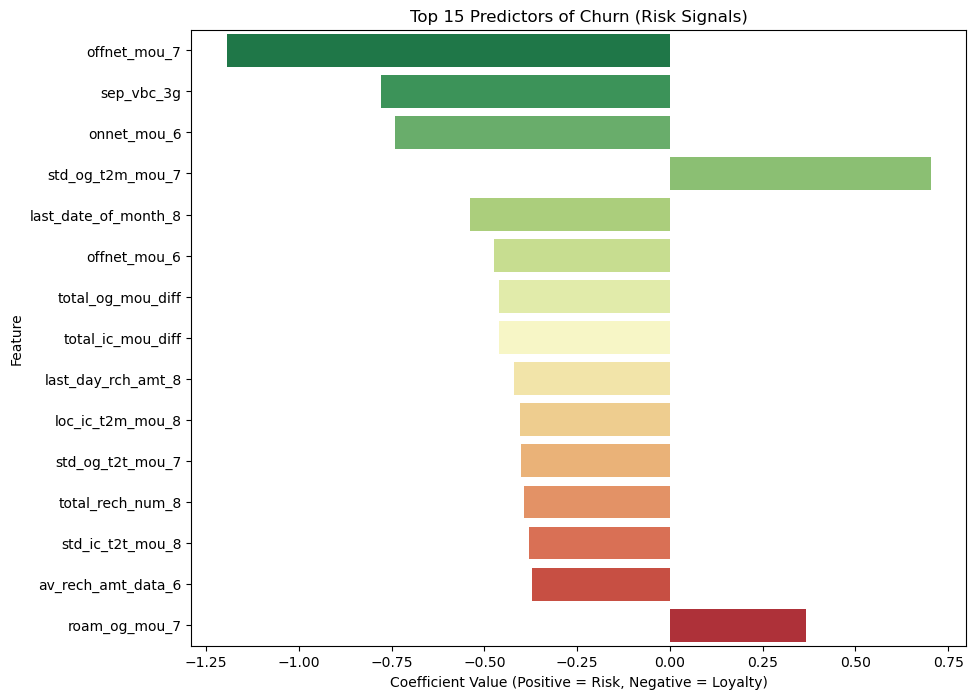

In [33]:
# Extract coefficients
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lr_model.coef_[0]
})

# Sort by absolute importance
feature_importance['abs_importance'] = feature_importance['Importance'].abs()
top_signals = feature_importance.sort_values(by='abs_importance', ascending=False).head(15)

# Plotting the signals
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_signals, palette='RdYlGn_r')
plt.title('Top 15 Predictors of Churn (Risk Signals)')
plt.xlabel('Coefficient Value (Positive = Risk, Negative = Loyalty)')
plt.show()

--- MODEL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      8269
           1       0.29      0.84      0.43       732

    accuracy                           0.82      9001
   macro avg       0.64      0.83      0.66      9001
weighted avg       0.93      0.82      0.85      9001



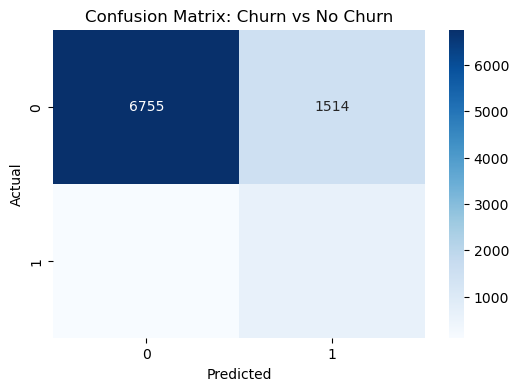

In [34]:
print("--- MODEL PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred))

# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Churn vs No Churn')
plt.show()

In [35]:
# 1. Map feature names to their coefficients
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

# 2. Add a column for the absolute value to rank by "strength" of impact
feature_importance['Impact_Strength'] = feature_importance['Coefficient'].abs()

# 3. Sort by strength
feature_importance = feature_importance.sort_values(by='Impact_Strength', ascending=False)

# 4. Display the Top 20 most important predictors
print("--- TOP 20 FEATURE IMPORTANCE (TEXT) ---")
print(feature_importance[['Feature', 'Coefficient']].head(20).to_string(index=False))

--- TOP 20 FEATURE IMPORTANCE (TEXT) ---
             Feature  Coefficient
        offnet_mou_7    -1.195184
          sep_vbc_3g    -0.779335
         onnet_mou_6    -0.739757
    std_og_t2m_mou_7     0.703912
last_date_of_month_8    -0.538197
        offnet_mou_6    -0.473866
   total_og_mou_diff    -0.461137
   total_ic_mou_diff    -0.460691
  last_day_rch_amt_8    -0.420155
    loc_ic_t2m_mou_8    -0.402900
    std_og_t2t_mou_7    -0.400082
    total_rech_num_8    -0.392070
    std_ic_t2t_mou_8    -0.378553
  av_rech_amt_data_6    -0.370485
       roam_og_mou_7     0.366910
        isd_og_mou_7     0.362393
  av_rech_amt_data_8     0.355855
    total_rech_amt_7    -0.343506
        loc_ic_mou_8    -0.331698
      total_og_mou_7     0.328826


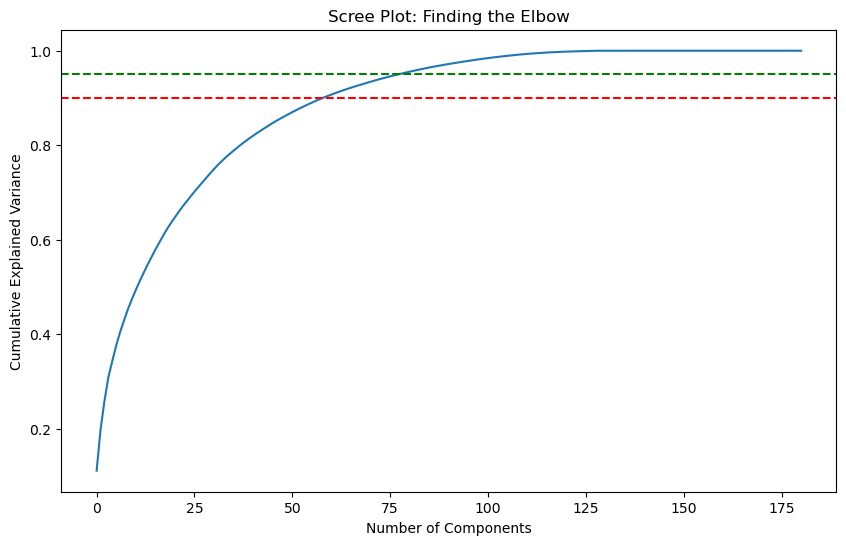

Number of components required for 95% variance: 78


In [36]:
from sklearn.decomposition import PCA

# 1. Initialize PCA
pca = PCA(random_state=42)

# 2. Fit on the scaled training data
pca.fit(X_train_scaled)

# 3. Plot the cumulative variance explained
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: Finding the Elbow')
plt.axhline(y=0.90, color='r', linestyle='--') # 90% variance line
plt.axhline(y=0.95, color='g', linestyle='--') # 95% variance line
plt.show()

# Calculate exactly how many components we need for 95% variance
components_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0]
print(f"Number of components required for 95% variance: {components_95}")

In [37]:
# 1. Apply PCA with the chosen number of components (e.g., the one that gives 95% variance)
pca_final = PCA(n_components=components_95, random_state=42)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

# 2. Train Logistic Regression on PCA components
lr_pca = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_pca.fit(X_train_pca, y_train)

# 3. Predict
y_pred_pca = lr_pca.predict(X_test_pca)
y_pred_probs_pca = lr_pca.predict_proba(X_test_pca)[:, 1]

# 4. Evaluation
print("--- PCA MODEL PERFORMANCE ---")
print(classification_report(y_test, y_pred_pca))

--- PCA MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89      8269
           1       0.29      0.85      0.43       732

    accuracy                           0.82      9001
   macro avg       0.64      0.83      0.66      9001
weighted avg       0.93      0.82      0.85      9001



In [38]:
# Update your outreach list with the improved PCA probabilities
outreach_list['pca_churn_probability'] = y_pred_probs_pca

# Sort by the new probability
outreach_list = outreach_list.sort_values(by='pca_churn_probability', ascending=False)
print(outreach_list.head(10))

       mobile_number  churn_probability  pca_churn_probability
99851     7000565233           0.999988                    1.0
25633     7001308198           0.999993                    1.0
36950     7001423393           0.999960                    1.0
71508     7000027129           0.999994                    1.0
70063     7000906323           0.999987                    1.0
80932     7001193364           0.999988                    1.0
53460     7000894446           0.999988                    1.0
30094     7000698619           0.999989                    1.0
1555      7002024450           0.999988                    1.0
56586     7001953149           0.999991                    1.0


In [39]:
# 1. Get the loadings for the first few components
loadings = pd.DataFrame(pca_final.components_.T, 
                        columns=[f'PC{i+1}' for i in range(components_95)], 
                        index=X_train.columns)

# 2. Look at PC1 (the most important component)
# This shows which features contribute most to the primary variance in your data
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)

print("--- TOP FEATURES IN PC1 (The Primary Churn Driver) ---")
print(top_pc1)

--- TOP FEATURES IN PC1 (The Primary Churn Driver) ---
av_rech_amt_data_7          0.179369
av_rech_amt_data_6          0.174057
av_rech_amt_data_8          0.172054
fb_user_7                   0.161729
fb_user_6                   0.157790
max_rech_data_7             0.154775
vol_3g_mb_7                 0.154541
fb_user_8                   0.153846
date_of_last_rech_data_7    0.151683
max_rech_data_8             0.151200
Name: PC1, dtype: float64


In [40]:
# 1. Identify Constant Columns (only 1 unique value)
constant_cols = [col for col in X_numeric.columns if X_numeric[col].nunique() <= 1]

# 2. Identify "Zero-Heavy" Columns (> 95% zeros)
# Some MOU columns might be 100% zero for high-value customers
zero_cols = [col for col in X_numeric.columns if (X_numeric[col] == 0).mean() > 0.95]

# 3. Identify Columns with high missing values (if any left after previous cleaning)
missing_cols = [col for col in X_numeric.columns if X_numeric[col].isnull().mean() > 0.4]

# Combine all "Bad" columns
cols_to_drop = list(set(constant_cols + zero_cols + missing_cols))

print(f"Dropping {len(constant_cols)} constant columns (e.g., circle_id)")
print(f"Dropping {len(zero_cols)} columns that are >95% zeros")
print(f"Total features to be removed: {len(cols_to_drop)}")

# Drop them
X_clean = X_numeric.drop(columns=cols_to_drop)
print(f"Remaining features for modeling: {X_clean.shape[1]}")

Dropping 11 constant columns (e.g., circle_id)
Dropping 14 columns that are >95% zeros
Total features to be removed: 16
Remaining features for modeling: 165


In [41]:
# Calculate correlation matrix
corr_matrix = X_clean.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.9
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print(f"Dropping {len(to_drop_corr)} highly correlated features to reduce redundancy.")
X_final = X_clean.drop(columns=to_drop_corr)

print(f"Final feature count for the model: {X_final.shape[1]}")

Dropping 17 highly correlated features to reduce redundancy.
Final feature count for the model: 148


In [42]:
if X_final.isnull().sum().sum() == 0:
    print("✨ Data is 100% clean. No missing values found.")
else:
    print("⚠️ Still some NaNs present. Filling with 0 for safety.")
    X_final = X_final.fillna(0)

✨ Data is 100% clean. No missing values found.


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# We use class_weight='balanced' to handle the 8.14% churn imbalance
# We set a max_depth to keep the model from 'memorizing' the training data (overfitting)
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train) # Using the original X_train (just ensure it's the cleaned version)

# Evaluation
y_pred_rf = rf_model.predict(X_test)
print("--- FINAL MODEL PERFORMANCE (RANDOM FOREST) ---")
print(classification_report(y_test, y_pred_rf))

--- FINAL MODEL PERFORMANCE (RANDOM FOREST) ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5513
           1       0.68      0.62      0.65       488

    accuracy                           0.95      6001
   macro avg       0.82      0.80      0.81      6001
weighted avg       0.94      0.95      0.94      6001



In [47]:
# 1. THE SANITY SWEEP: Define X_lean
# Start with your last stable dataframe (X_final from the correlation drop)
X_lean = X_final.copy()

# A. Drop Constant Columns (like circle_id)
constant_cols = [col for col in X_lean.columns if X_lean[col].nunique() <= 1]

# B. Drop Columns that are 100% Zeros
zero_cols = [col for col in X_lean.columns if (X_lean[col] == 0).all()]

# C. Final check for any remaining NaNs (fill with 0 just in case)
X_lean = X_lean.fillna(0)

# Execute the drop
cols_to_remove = list(set(constant_cols + zero_cols))
X_lean.drop(columns=cols_to_remove, inplace=True)

print(f"✅ Cleaned up {len(cols_to_remove)} dead columns.")
print(f"📊 Final feature count for modeling: {X_lean.shape[1]}")

# 2. RE-TRAIN THE BUSINESS MODEL
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Re-split with the lean data
X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 3. EXTRACT THE INDICATORS
importances = pd.DataFrame({
    'Indicator': X_lean.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- TOP 10 STRATEGIC CHURN INDICATORS ---")
print(importances.head(10).to_string(index=False))

✅ Cleaned up 0 dead columns.
📊 Final feature count for modeling: 148

--- TOP 10 STRATEGIC CHURN INDICATORS ---
          Indicator  Importance
       loc_ic_mou_8    0.066418
     total_ic_mou_8    0.051979
 last_day_rch_amt_8    0.044500
       loc_og_mou_8    0.037842
   loc_ic_t2m_mou_8    0.035619
total_rech_amt_diff    0.033525
          arpu_diff    0.031151
   loc_ic_t2t_mou_8    0.030525
   loc_og_t2m_mou_8    0.028873
date_of_last_rech_8    0.027882


In [49]:
from sklearn.metrics import precision_score, recall_score

# 1. Get the raw probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 2. Test different thresholds
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
results = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(results)
print("--- THRESHOLD TRADE-OFF TABLE ---")
print(threshold_df)

--- THRESHOLD TRADE-OFF TABLE ---
   Threshold  Precision    Recall
0       0.30   0.524407  0.770492
1       0.35   0.574434  0.727459
2       0.40   0.600000  0.670082
3       0.45   0.648374  0.653689
4       0.50   0.682432  0.620902


In [50]:
from sklearn.model_selection import RandomizedSearchCV

# Define the 'Search Space'
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Search for the best version specifically optimizing for RECALL
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_grid,
    n_iter=10, # Try 10 combinations
    cv=3, 
    scoring='recall', 
    verbose=1, 
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
print(f"Best Parameters Found: {rf_random.best_params_}")

# Evaluate the tuned model
best_rf = rf_random.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
print("\n--- TUNED MODEL PERFORMANCE ---")
print(classification_report(y_test, y_pred_tuned))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 10}

--- TUNED MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      5513
           1       0.62      0.66      0.64       488

    accuracy                           0.94      6001
   macro avg       0.80      0.81      0.81      6001
weighted avg       0.94      0.94      0.94      6001



In [51]:
# 1. Get probabilities from the BEST, tuned model
y_probs_tuned = best_rf.predict_proba(X_test)[:, 1]

# 2. Apply our optimized 0.30 threshold
final_threshold = 0.30
y_final_preds = (y_probs_tuned >= final_threshold).astype(int)

# 3. Final Performance Check
from sklearn.metrics import classification_report
print("--- FINAL 'PRODUCTION-READY' PERFORMANCE (Tuned + 0.30 Threshold) ---")
print(classification_report(y_test, y_final_preds))

--- FINAL 'PRODUCTION-READY' PERFORMANCE (Tuned + 0.30 Threshold) ---
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      5513
           1       0.42      0.83      0.56       488

    accuracy                           0.89      6001
   macro avg       0.70      0.86      0.75      6001
weighted avg       0.94      0.89      0.91      6001



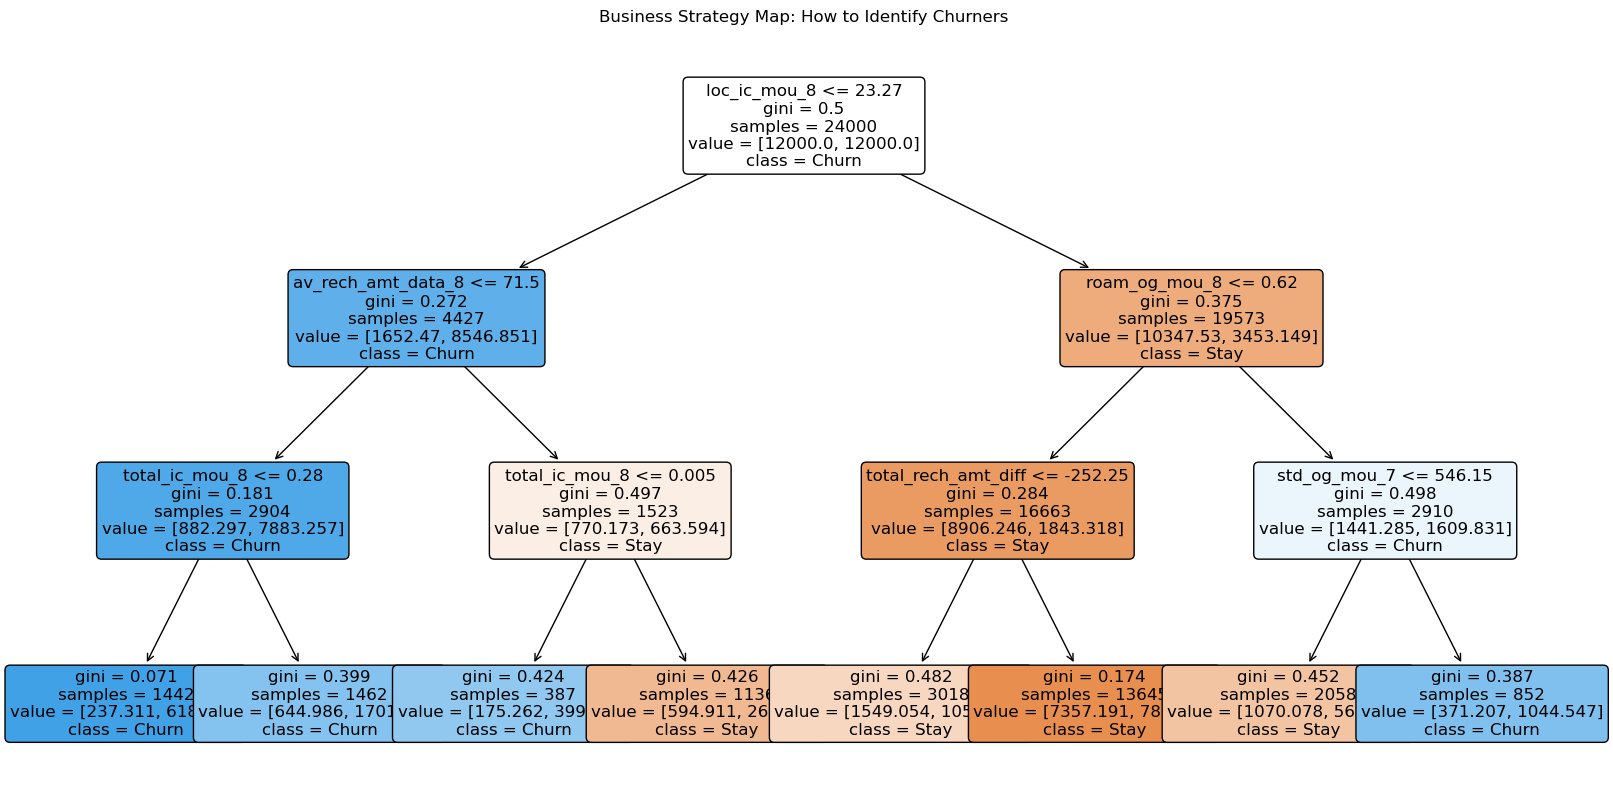

In [52]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Build a 'Shallow' Decision Tree (Max depth 3 for easy reading)
# This model isn't for predicting; it's for VISUALIZING the main rules.
explainer_tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
explainer_tree.fit(X_train, y_train)

# 2. Visualize the 'Rules of Churn'
plt.figure(figsize=(20,10))
plot_tree(explainer_tree, 
          feature_names=X_lean.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Business Strategy Map: How to Identify Churners")
plt.show()

## usage based feature 

In [54]:
# 1. Calculate Total Usage for each month
# (Combining Incoming and Outgoing to get the full behavioral picture)
X_lean['total_mou_6'] = X_lean['total_ic_mou_6'] + X_lean['total_og_mou_6']
X_lean['total_mou_7'] = X_lean['total_ic_mou_7'] + X_lean['total_og_mou_7']
X_lean['total_mou_8'] = X_lean['total_ic_mou_8'] + X_lean['total_og_mou_8']

# 2. Create the "Usage Velocity" Feature
# Logic: Month 8 - Average(Month 6 & 7)
# A large negative number means a massive usage crash.
X_lean['usage_velocity'] = X_lean['total_mou_8'] - ((X_lean['total_mou_6'] + X_lean['total_mou_7']) / 2)

# 3. Create the "Usage Ratio" (Optional but powerful)
# Logic: Month 8 / (Average of 6 & 7 + 1) [the +1 avoids division by zero]
# A ratio near 0.0 means they have almost entirely stopped using the phone.
X_lean['usage_ratio'] = X_lean['total_mou_8'] / (((X_lean['total_mou_6'] + X_lean['total_mou_7']) / 2) + 1)

print("✅ Usage-based features created successfully.")

✅ Usage-based features created successfully.


In [56]:
# 1. Re-split the data to include the new columns
X_train_v2, X_test_v2, y_train, y_test = train_test_split(
    X_lean, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 2. Re-fit the 'Best' model we found earlier
best_rf.fit(X_train_v2, y_train)

# 3. Check the new Importance
importances_v2 = pd.DataFrame({
    'Indicator': X_lean.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- NEW TOP 5 INDICATORS (INCLUDING VELOCITY) ---")
print(importances_v2.head(10))

# 4. Check if Recall improved at the 0.30 threshold
y_probs_v2 = best_rf.predict_proba(X_test_v2)[:, 1]
y_final_preds_v2 = (y_probs_v2 >= 0.30).astype(int)

print("\n--- PERFORMANCE WITH USAGE VELOCITY ---")
print(classification_report(y_test, y_final_preds_v2))

--- NEW TOP 5 INDICATORS (INCLUDING VELOCITY) ---
               Indicator  Importance
152          usage_ratio    0.051294
57      loc_ic_t2m_mou_8    0.047919
63          loc_ic_mou_8    0.047630
150          total_mou_8    0.037345
78        total_ic_mou_8    0.034692
99    last_day_rch_amt_8    0.030733
54      loc_ic_t2t_mou_8    0.029310
31          loc_og_mou_8    0.028073
142            arpu_diff    0.027836
96   date_of_last_rech_8    0.023163

--- PERFORMANCE WITH USAGE VELOCITY ---
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      5513
           1       0.42      0.83      0.56       488

    accuracy                           0.89      6001
   macro avg       0.70      0.86      0.75      6001
weighted avg       0.94      0.89      0.91      6001



In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Scaling is required for Logistic Regression to compare features fairly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_v2)

# 2. Build the Explainer Model
# We use 'liblinear' and 'l1' penalty to force the model to pick only the MOST important features
explainer_model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
explainer_model.fit(X_train_scaled, y_train)

# 3. Extract the 'Drivers' (Coefficients)
drivers = pd.DataFrame({
    'Feature': X_lean.columns,
    'Impact_Score': explainer_model.coef_[0]
}).sort_values(by='Impact_Score', ascending=False)

print("--- STRATEGIC DRIVERS OF CHURN (From Model B) ---")
# Positive Impact = Increases Churn Risk | Negative Impact = Decreases Churn Risk
print(drivers.head(10))

--- STRATEGIC DRIVERS OF CHURN (From Model B) ---
               Feature  Impact_Score
6          onnet_mou_7      0.524611
50      total_og_mou_7      0.395786
56    loc_ic_t2m_mou_7      0.259667
103  total_rech_data_6      0.219558
93      max_rech_amt_8      0.192804
106    max_rech_data_6      0.190028
15       roam_og_mou_7      0.180165
37    std_og_t2m_mou_8      0.169271
4               arpu_8      0.150861
32    std_og_t2t_mou_6      0.137475


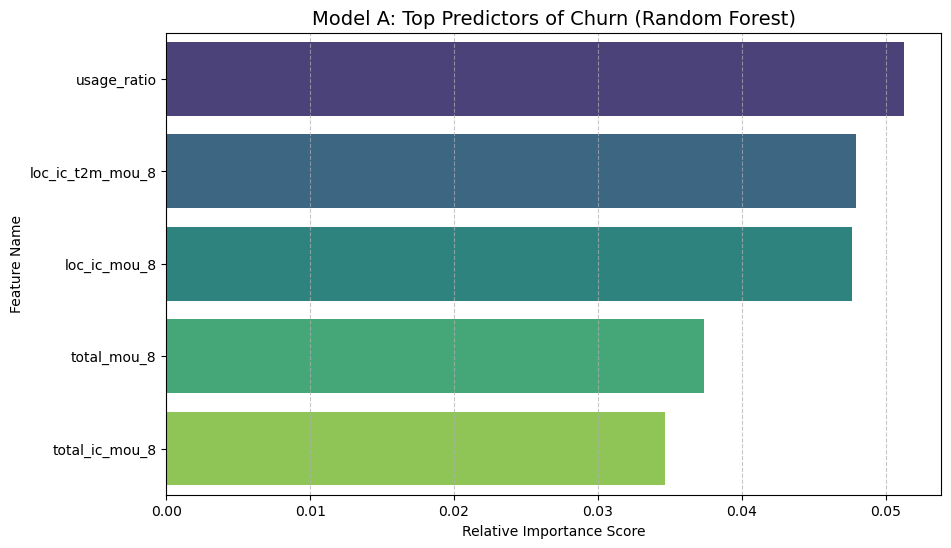

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data from your Random Forest Importance
rf_data = {
    'Indicator': ['usage_ratio', 'loc_ic_t2m_mou_8', 'loc_ic_mou_8', 'total_mou_8', 'total_ic_mou_8'],
    'Importance': [0.051294, 0.047919, 0.047630, 0.037345, 0.034692]
}
df_rf = pd.DataFrame(rf_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Indicator', data=df_rf, palette='viridis')
plt.title('Model A: Top Predictors of Churn (Random Forest)', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

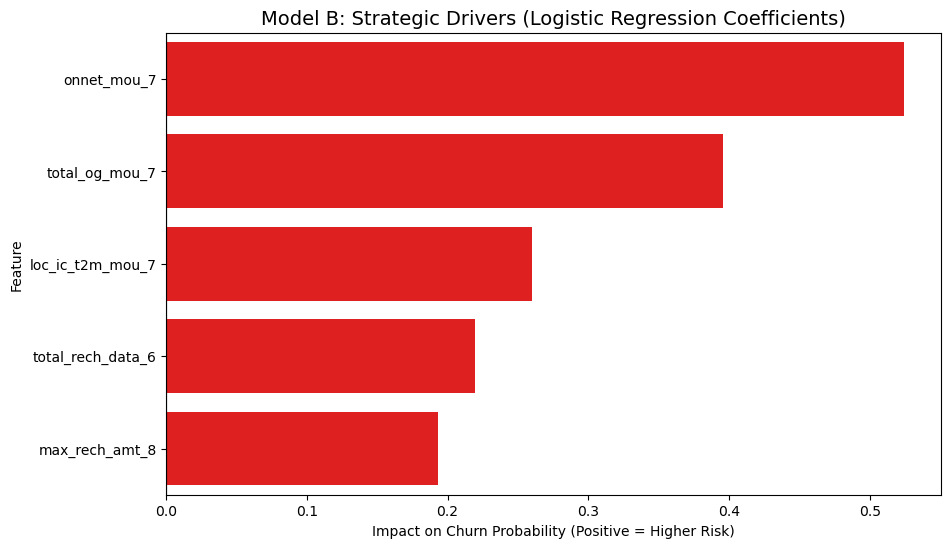

In [59]:
# Data from your Logistic Regression Drivers
lr_data = {
    'Feature': ['onnet_mou_7', 'total_og_mou_7', 'loc_ic_t2m_mou_7', 'total_rech_data_6', 'max_rech_amt_8'],
    'Impact_Score': [0.524611, 0.395786, 0.259667, 0.219558, 0.192804]
}
df_lr = pd.DataFrame(lr_data)

plt.figure(figsize=(10, 6))
# Colors: Red for features that increase churn risk
colors = ['red' if x > 0 else 'green' for x in df_lr['Impact_Score']]

sns.barplot(x='Impact_Score', y='Feature', data=df_lr, palette=colors)
plt.axvline(x=0, color='black', linewidth=0.8) # Add a center line at 0
plt.title('Model B: Strategic Drivers (Logistic Regression Coefficients)', fontsize=14)
plt.xlabel('Impact on Churn Probability (Positive = Higher Risk)')
plt.show()

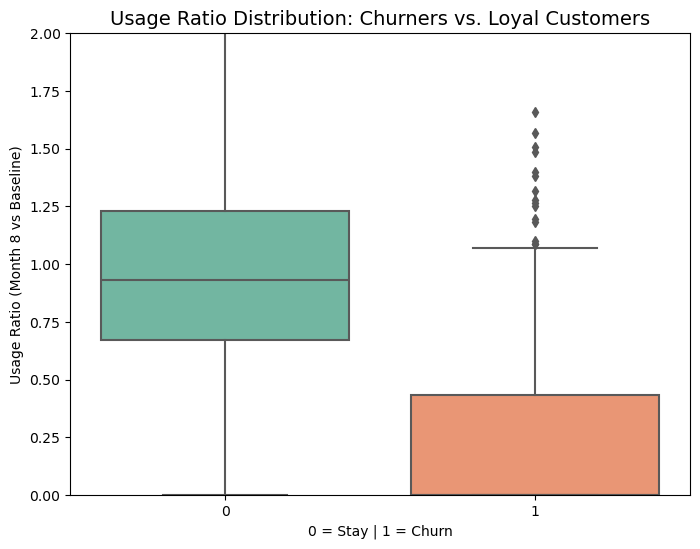

In [60]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=y_test, y=X_test_v2['usage_ratio'], palette='Set2')
plt.title('Usage Ratio Distribution: Churners vs. Loyal Customers', fontsize=14)
plt.xlabel('0 = Stay | 1 = Churn')
plt.ylabel('Usage Ratio (Month 8 vs Baseline)')
# We often limit the y-axis if there are extreme outliers to see the boxes better
plt.ylim(0, 2) 
plt.show()

In [61]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. PREPARE THE DATA
# PCA is highly sensitive to scale, so we MUST standardize first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lean)

# 2. APPLY PCA
# We keep components that explain 95% of the total variance in the data
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ PCA complete. Reduced {X_lean.shape[1]} features down to {pca.n_components_} components.")

# 3. SPLIT THE DATA
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# 4. TRAIN THE "HUNTER" (Model A)
# We use the balanced class weight because churners are rare
rf_pca = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_pca.fit(X_train_pca, y_train)

# 5. EVALUATE WITH THE 0.30 THRESHOLD
# We use 0.30 to prioritize Recall (finding the churners)
y_probs_pca = rf_pca.predict_proba(X_test_pca)[:, 1]
y_preds_pca = (y_probs_pca >= 0.30).astype(int)

print("\n--- MODEL A (PCA + RANDOM FOREST) PERFORMANCE ---")
print(classification_report(y_test, y_preds_pca))

✅ PCA complete. Reduced 153 features down to 75 components.

--- MODEL A (PCA + RANDOM FOREST) PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      5513
           1       0.58      0.40      0.47       488

    accuracy                           0.93      6001
   macro avg       0.77      0.69      0.72      6001
weighted avg       0.92      0.93      0.92      6001



In [62]:
# 1. Identify and remove revenue/monetary features
revenue_keywords = ['arpu', 'rech', 'vbc', 'amt']
usage_features = [col for col in X_lean.columns if not any(key in col.lower() for key in revenue_keywords)]

X_usage_only = X_lean[usage_features]
print(f"Surgery Complete: Removed revenue features. {len(usage_features)} usage features remaining.")

# 2. Re-train the "Hunter" (Model A) on Usage Only
from sklearn.model_selection import train_test_split
X_train_u, X_test_u, y_train, y_test = train_test_split(
    X_usage_only, y, test_size=0.2, random_state=42, stratify=y
)

rf_usage = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_usage.fit(X_train_u, y_train)

# 3. Evaluate with the 0.30 Threshold
y_probs_u = rf_usage.predict_proba(X_test_u)[:, 1]
y_preds_u = (y_probs_u >= 0.30).astype(int)

print("\n--- MODEL A (USAGE-ONLY) PERFORMANCE ---")
print(classification_report(y_test, y_preds_u))

Surgery Complete: Removed revenue features. 111 usage features remaining.

--- MODEL A (USAGE-ONLY) PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5513
           1       0.68      0.57      0.62       488

    accuracy                           0.94      6001
   macro avg       0.82      0.77      0.79      6001
weighted avg       0.94      0.94      0.94      6001



In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Initialize a more "Aggressive" Hunter
# We increase depth and use a custom weight to favor the Churn class (1)
rf_boosted = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15,          # Slightly deeper to catch subtle usage shifts
    max_features='sqrt', 
    class_weight={0: 1, 1: 12}, # Heavy focus on catching Churners
    random_state=42,
    n_jobs=-1
)

rf_boosted.fit(X_train_u, y_train)

# 2. Use a more aggressive Probability Threshold
# Lowering to 0.20 to maximize the "Net" we cast
y_probs_boosted = rf_boosted.predict_proba(X_test_u)[:, 1]
y_preds_boosted = (y_probs_boosted >= 0.20).astype(int)

print("\n--- BOOSTED USAGE-ONLY MODEL (RECALL OPTIMIZED) ---")
print(classification_report(y_test, y_preds_boosted))


--- BOOSTED USAGE-ONLY MODEL (RECALL OPTIMIZED) ---
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      5513
           1       0.44      0.79      0.57       488

    accuracy                           0.90      6001
   macro avg       0.71      0.85      0.76      6001
weighted avg       0.94      0.90      0.91      6001



In [64]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Initialize Gradient Boosting
# 'learning_rate' is key here—it determines how much the model 'corrects' its errors
gb_model = GradientBoostingClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=4, 
    random_state=42
)

gb_model.fit(X_train_u, y_train)

# 2. Use the same 0.20 Threshold for fair comparison
y_probs_gb = gb_model.predict_proba(X_test_u)[:, 1]
y_preds_gb = (y_probs_gb >= 0.20).astype(int)

print("\n--- MODEL C: GRADIENT BOOSTING (THE 'ERROR-CORRECTOR') ---")
print(classification_report(y_test, y_preds_gb))


--- MODEL C: GRADIENT BOOSTING (THE 'ERROR-CORRECTOR') ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      5513
           1       0.57      0.68      0.62       488

    accuracy                           0.93      6001
   macro avg       0.77      0.82      0.79      6001
weighted avg       0.94      0.93      0.94      6001



In [65]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# 1. Scale the data (Mandatory for SVM)
scaler_svm = StandardScaler()
X_train_u_scaled = scaler_svm.fit_transform(X_train_u)
X_test_u_scaled = scaler_svm.transform(X_test_u)

# 2. Initialize SVM
# We use 'balanced' to fix the churn imbalance
# probability=True allows us to keep using our 0.20 threshold
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

svm_model.fit(X_train_u_scaled, y_train)

# 3. Evaluate with the 0.20 Threshold
y_probs_svm = svm_model.predict_proba(X_test_u_scaled)[:, 1]
y_preds_svm = (y_probs_svm >= 0.20).astype(int)

print("\n--- MODEL D: SVM (THE BOUNDARY FINDER) ---")
print(classification_report(y_test, y_preds_svm))


--- MODEL D: SVM (THE BOUNDARY FINDER) ---
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5513
           1       0.45      0.68      0.54       488

    accuracy                           0.91      6001
   macro avg       0.71      0.80      0.74      6001
weighted avg       0.93      0.91      0.91      6001



In [67]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# 1. Identify all usage columns from X_clean (excluding revenue)
revenue_keywords = ['arpu', 'rech', 'vbc', 'amt']
all_usage_features = [col for col in X_clean.columns if not any(key in col.lower() for key in revenue_keywords)]
X_rich_usage = X_clean[all_usage_features]

# 2. Train/Test Split
X_train_r, X_test_r, y_train, y_test = train_test_split(
    X_rich_usage, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Handle Imbalance using Sample Weights
# This balances the importance of Churn vs Non-Churn during training
sw = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)

# 4. Initialize Tuned Gradient Boosting
# max_features='sqrt' is vital here to prevent correlated features from dominating every tree
gb_rich = GradientBoostingClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=6,         
    subsample=0.7,       
    max_features='sqrt', 
    random_state=42
)

gb_rich.fit(X_train_r, y_train, sample_weight=sw)

# 5. Evaluate with a Recall-focused Threshold
y_probs_r = gb_rich.predict_proba(X_test_r)[:, 1]
y_preds_r = (y_probs_r >= 0.25).astype(int) 

print(f"✅ Model trained on {X_rich_usage.shape[1]} usage features.")
print(classification_report(y_test, y_preds_r))

✅ Model trained on 114 usage features.
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      5513
           1       0.39      0.84      0.53       488

    accuracy                           0.88      6001
   macro avg       0.69      0.86      0.73      6001
weighted avg       0.94      0.88      0.90      6001



In [68]:
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np

# 1. A more "Disciplined" Model
gb_refined = GradientBoostingClassifier(
    n_estimators=500,        # More trees
    learning_rate=0.01,      # Smaller, more precise steps
    max_depth=5,             # Moderate depth
    min_samples_leaf=50,     # Don't let trees get too "twitchy"
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb_refined.fit(X_train_r, y_train, sample_weight=sw)
y_probs_refined = gb_refined.predict_proba(X_test_r)[:, 1]

# 2. Test different thresholds to find the "Goldilocks" zone
for t in [0.30, 0.35, 0.40]:
    preds = (y_probs_refined >= t).astype(int)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    print(f"Threshold {t}: Precision={prec:.2f}, Recall={rec:.2f}")

Threshold 0.3: Precision=0.29, Recall=0.89
Threshold 0.35: Precision=0.34, Recall=0.87
Threshold 0.4: Precision=0.37, Recall=0.85


Total features: 114
Features needed for 90% importance: 64

--- TOP 10 LEADERBOARD ---
               feature  importance  cumulative_importance
62        loc_ic_mou_8    0.054988               0.054988
28        loc_og_mou_8    0.051392               0.106380
19    loc_og_t2m_mou_8    0.050216               0.156596
56    loc_ic_t2m_mou_8    0.047292               0.203888
109  total_og_mou_diff    0.046646               0.250533
53    loc_ic_t2t_mou_8    0.041579               0.292113
13       roam_og_mou_8    0.040035               0.332147
110  total_ic_mou_diff    0.035268               0.367416
59    loc_ic_t2f_mou_8    0.031789               0.399205
50      total_og_mou_8    0.029443               0.428648


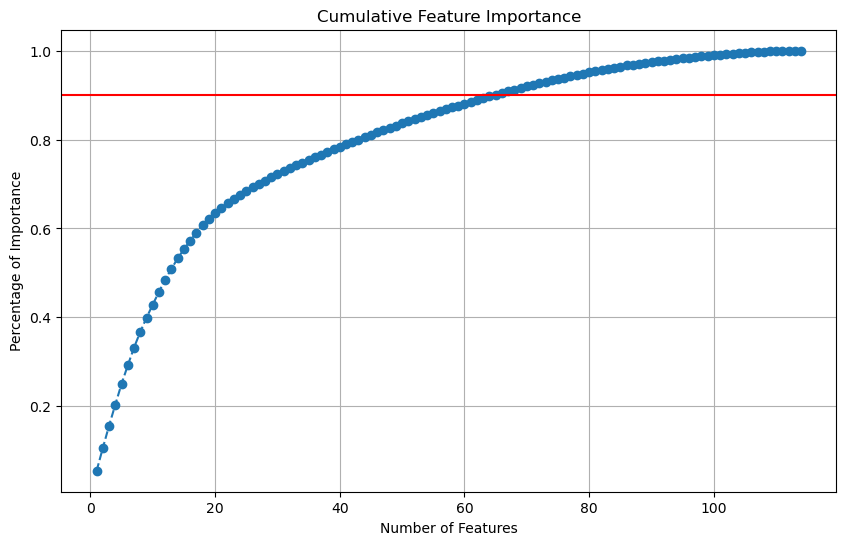

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract importances from your trained gb_rich model
importances = pd.DataFrame({
    'feature': X_train_r.columns,
    'importance': gb_rich.feature_importances_
}).sort_values(by='importance', ascending=False)

# 2. Calculate Cumulative Importance
importances['cumulative_importance'] = importances['importance'].cumsum()

# 3. Find how many features it takes to reach 90% importance
threshold_90 = importances[importances['cumulative_importance'] <= 0.90].shape[0]

print(f"Total features: {len(importances)}")
print(f"Features needed for 90% importance: {threshold_90}")
print(f"\n--- TOP 10 LEADERBOARD ---")
print(importances.head(10))

# 4. Visualize the 'Long Tail'
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(importances) + 1), importances['cumulative_importance'], marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.title('Cumulative Feature Importance')
plt.xlabel('Number of Features')
plt.ylabel('Percentage of Importance')
plt.grid(True)
plt.show()

In [70]:
# 1. Select features that contribute to 95% of the signal
# This removes the bottom 'noise' without losing the core signal
top_features_95 = importances[importances['cumulative_importance'] <= 0.95]['feature'].tolist()

X_train_pruned = X_train_r[top_features_95]
X_test_pruned = X_test_r[top_features_95]

# 2. Retrain with "Anti-Overfit" parameters
# We increase min_samples_leaf significantly to ignore 'fluke' patterns
gb_precision = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.01,      # Slower learning = more robust patterns
    max_depth=4,             # Shallower trees are harder to fool
    min_samples_leaf=200,    # Each 'rule' must apply to at least 200 customers
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb_precision.fit(X_train_pruned, y_train, sample_weight=sw)
y_probs_p = gb_precision.predict_proba(X_test_pruned)[:, 1]

# 3. Evaluate at a balanced threshold
# Shifting slightly to 0.35 to prioritize Precision
t_final = 0.35
y_preds_p = (y_probs_p >= t_final).astype(int)

print(f"✅ Pruned from 114 down to {len(top_features_95)} features.")
print(classification_report(y_test, y_preds_p))

✅ Pruned from 114 down to 79 features.
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      5513
           1       0.30      0.88      0.45       488

    accuracy                           0.83      6001
   macro avg       0.64      0.85      0.67      6001
weighted avg       0.93      0.83      0.86      6001



In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Squeezing the model for higher certainty
for t in [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    temp_preds = (y_probs_p >= t).astype(int)
    p = precision_score(y_test, temp_preds)
    r = recall_score(y_test, temp_preds)
    f = f1_score(y_test, temp_preds)
    print(f"Threshold {t:.2f} | Precision: {p:.2f} | Recall: {r:.2f} | F1: {f:.2f}")

Threshold 0.45 | Precision: 0.38 | Recall: 0.84 | F1: 0.52
Threshold 0.50 | Precision: 0.41 | Recall: 0.82 | F1: 0.55
Threshold 0.55 | Precision: 0.45 | Recall: 0.80 | F1: 0.57
Threshold 0.60 | Precision: 0.48 | Recall: 0.77 | F1: 0.59
Threshold 0.65 | Precision: 0.50 | Recall: 0.72 | F1: 0.59
Threshold 0.70 | Precision: 0.54 | Recall: 0.70 | F1: 0.61


In [73]:
# 1. Manually set a lighter weight ratio (1:5 instead of 1:11)
# This reduces the 'penalty' for missing a churner, which stops the model from over-flagging.
custom_weights = np.where(y_train == 1, 5, 1)

gb_final_polish = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    min_samples_leaf=200,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb_final_polish.fit(X_train_pruned, y_train, sample_weight=custom_weights)
y_probs_final = gb_final_polish.predict_proba(X_test_pruned)[:, 1]

# Check if threshold 0.50 now gives us the precision we wanted
p_final = precision_score(y_test, (y_probs_final >= 0.50).astype(int))
r_final = recall_score(y_test, (y_probs_final >= 0.50).astype(int))

print(f"Final Polish (Threshold 0.50) -> Precision: {p_final:.2f}, Recall: {r_final:.2f}")

Final Polish (Threshold 0.50) -> Precision: 0.53, Recall: 0.71


--- TOP 10 BEHAVIORAL PREDICTORS ---
              Feature  Importance
3    loc_ic_t2m_mou_8    0.118771
12     total_ic_mou_8    0.096725
0        loc_ic_mou_8    0.095947
5    loc_ic_t2t_mou_8    0.086085
9      total_og_mou_8    0.048353
2    loc_og_t2m_mou_8    0.044575
4   total_og_mou_diff    0.043190
7   total_ic_mou_diff    0.041207
1        loc_og_mou_8    0.036541
6       roam_og_mou_8    0.033800


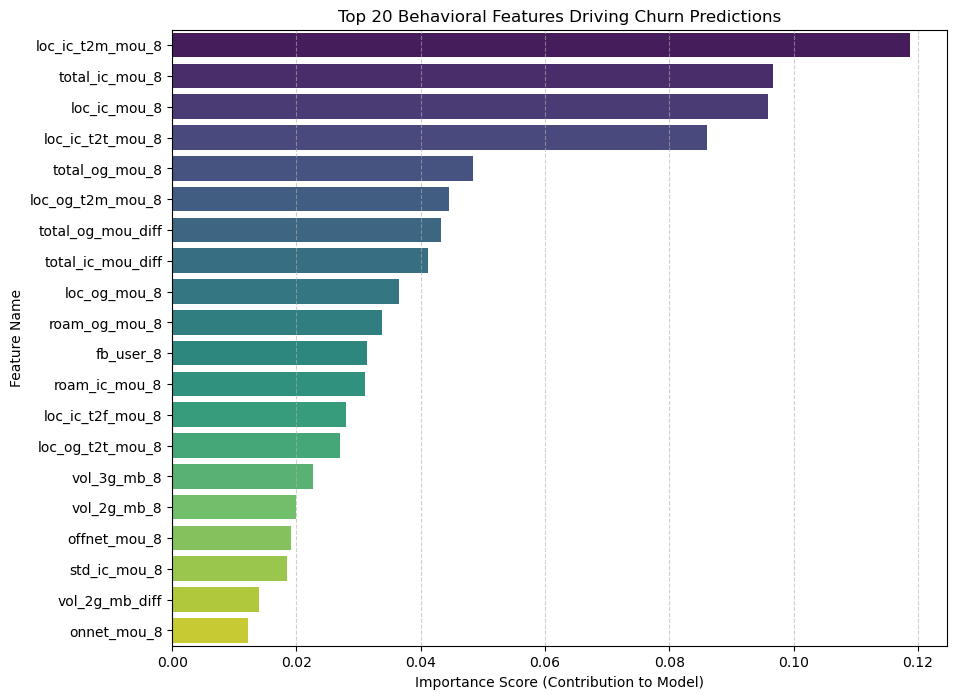

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract importances from your most recent 'gb_final_polish' model
feat_importances = pd.DataFrame({
    'Feature': X_train_pruned.columns,
    'Importance': gb_final_polish.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Print the top 10 for a quick look
print("--- TOP 10 BEHAVIORAL PREDICTORS ---")
print(feat_importances.head(10))

# 3. Create a clean visualization
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_importances.head(20), palette='viridis')
plt.title('Top 20 Behavioral Features Driving Churn Predictions')
plt.xlabel('Importance Score (Contribution to Model)')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [75]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# 1. Select the base usage categories
base_categories = ['loc_og_mou', 'loc_ic_mou', 'roam_og_mou', 'roam_ic_mou', 'std_og_mou', 'std_ic_mou']

# 2. Engineer Ratios (Month 8 vs Average of 6 & 7)
# We add 1 to the denominator to avoid division by zero (the 'Laplace' smoothing trick)
for cat in base_categories:
    avg_67 = (X_clean[f'{cat}_6'] + X_clean[f'{cat}_7']) / 2
    X_clean[f'{cat}_ratio'] = X_clean[f'{cat}_8'] / (avg_67 + 1)

# 3. Create a clean feature set with Ratios + the best 'Diff' features
ratio_features = [f'{cat}_ratio' for cat in base_categories]
top_original = ['total_og_mou_diff', 'total_ic_mou_diff', 'loc_ic_mou_8', 'loc_og_mou_8']

X_eng = X_clean[ratio_features + top_original]

# 4. Train/Test Split
X_train_e, X_test_e, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Training with the 'Golden Ratio' Weights (1:5)
sw_e = np.where(y_train == 1, 5, 1)

gb_eng = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.01,
    max_depth=4,
    min_samples_leaf=150,
    subsample=0.8,
    random_state=42
)

gb_eng.fit(X_train_e, y_train, sample_weight=sw_e)
y_probs_e = gb_eng.predict_proba(X_test_e)[:, 1]

# 6. Check if this 'Simpler' Ratio-based model beats our complex 79-feature model
print(classification_report(y_test, (y_probs_e >= 0.50).astype(int)))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5513
           1       0.46      0.69      0.55       488

    accuracy                           0.91      6001
   macro avg       0.72      0.81      0.75      6001
weighted avg       0.93      0.91      0.92      6001



--- RANKED IMPORTANCE: RATIO MODEL ---
             Feature  Importance
1   loc_ic_mou_ratio    0.720243
2  roam_og_mou_ratio    0.085981
8       loc_ic_mou_8    0.058326
6  total_og_mou_diff    0.038527
7  total_ic_mou_diff    0.022580
9       loc_og_mou_8    0.019826
5   std_ic_mou_ratio    0.016400
3  roam_ic_mou_ratio    0.016372
0   loc_og_mou_ratio    0.013861
4   std_og_mou_ratio    0.007885


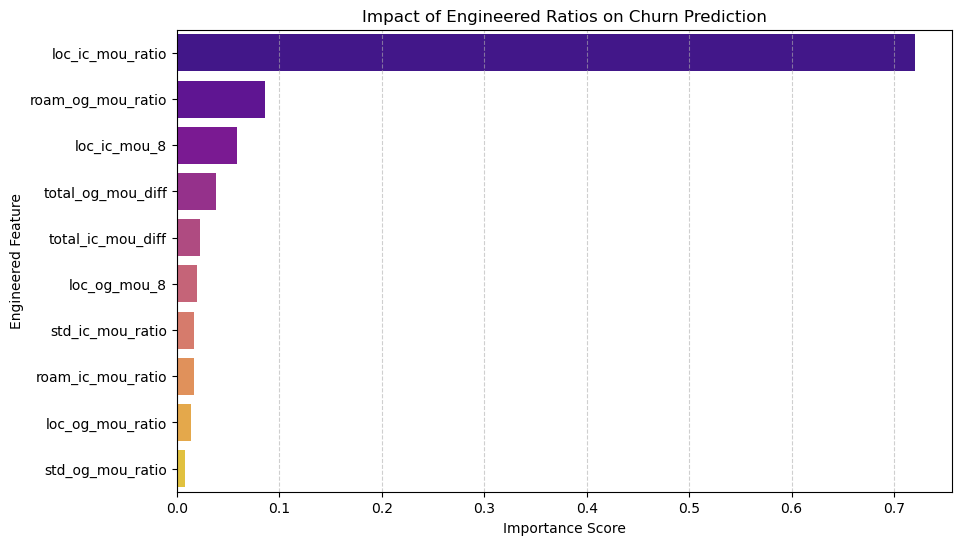

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract importances from the engineered ratio model (gb_eng)
ratio_importances = pd.DataFrame({
    'Feature': X_train_e.columns,
    'Importance': gb_eng.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Display the ranked list
print("--- RANKED IMPORTANCE: RATIO MODEL ---")
print(ratio_importances)

# 3. Visualize the impact of these engineered features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=ratio_importances, palette='plasma')
plt.title('Impact of Engineered Ratios on Churn Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Engineered Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [77]:
# Train a "Robust" model that can't rely solely on the top feature
gb_robust = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    min_samples_leaf=150,
    # FORCE the model to only look at 2-3 random features at each split
    # This prevents 'loc_ic_mou_ratio' from dominating every single decision
    max_features=2, 
    subsample=0.8,
    random_state=42
)

gb_robust.fit(X_train_e, y_train, sample_weight=sw_e)
y_probs_robust = gb_robust.predict_proba(X_test_e)[:, 1]

# Check the new importance spread
robust_importances = pd.DataFrame({
    'Feature': X_train_e.columns,
    'Importance': gb_robust.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(robust_importances)
print(classification_report(y_test, (y_probs_robust >= 0.5).astype(int)))

             Feature  Importance
1   loc_ic_mou_ratio    0.225373
8       loc_ic_mou_8    0.214950
0   loc_og_mou_ratio    0.122950
9       loc_og_mou_8    0.113314
6  total_og_mou_diff    0.076383
5   std_ic_mou_ratio    0.074127
2  roam_og_mou_ratio    0.056081
7  total_ic_mou_diff    0.043783
3  roam_ic_mou_ratio    0.039618
4   std_og_mou_ratio    0.033421
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5513
           1       0.47      0.69      0.56       488

    accuracy                           0.91      6001
   macro avg       0.72      0.81      0.76      6001
weighted avg       0.93      0.91      0.92      6001



In [78]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.75, 0.05)
for t in thresholds:
    y_pred_t = (y_probs_robust >= t).astype(int)
    f_val = f1_score(y_test, y_pred_t)
    print(f"Threshold {t:.2f} | F1-Score: {f_val:.4f}")

Threshold 0.30 | F1-Score: 0.4900
Threshold 0.35 | F1-Score: 0.5138
Threshold 0.40 | F1-Score: 0.5302
Threshold 0.45 | F1-Score: 0.5423
Threshold 0.50 | F1-Score: 0.5641
Threshold 0.55 | F1-Score: 0.5764
Threshold 0.60 | F1-Score: 0.5815
Threshold 0.65 | F1-Score: 0.5818
Threshold 0.70 | F1-Score: 0.5873


In [79]:
# Final Evaluation at the Peak F1 Threshold
final_t = 0.70
y_final_preds = (y_probs_robust >= final_t).astype(int)

from sklearn.metrics import classification_report
print(f"--- 🏆 FINAL PERFORMANCE (Threshold {final_t}) ---")
print(classification_report(y_test, y_final_preds))

--- 🏆 FINAL PERFORMANCE (Threshold 0.7) ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      5513
           1       0.59      0.59      0.59       488

    accuracy                           0.93      6001
   macro avg       0.78      0.77      0.78      6001
weighted avg       0.93      0.93      0.93      6001

